# Static Word Embeddings

## Static word Embeddings
In class you discussed how there are models like **GloVe**, **Word2Vec** and **fastText** that, when trained on a corpus, produce a vectorial representation of words based on the context. These models produce what are called static embeddings, meaning that there is a singular vector for each word that is a weighted average of all the meanings that the word can have.

For example, the word **right** can have different meanings:

1.   It looks **right** -> right as in correct
2.   The phone is on your **right** -> right as in position

But we will get a single vector for the word **right**, which includes both meanings.


**Useful NLP libraries**

There are many useful python NLP libraries:


* [NLTK](https://www.nltk.org), Natural Language Toolkit is a platform that includes many resources for building Python programs and models to work with text.  Here can be found datasets and libraries for classification, tokenization, stemming, tagging, parsing, and semantic reasoning.
* [SpaCy](https://spacy.io), which is a library useful for creating models, chatbots, and programs for document and text analysis (part-of-speech tagging, dependency parsing, text categorization, named entity recognition).
* [HuggingFace 🤗](https://huggingface.co), that is a machine learning and data science platform useful for building, deployment, and training of machine learning models.
* [Gensim](https://radimrehurek.com/gensim/auto_examples/index.html#other-resources), which is library for topic modeling, information retrieval and other natural language processing resources, models and functionalities. This library also offers models to train word vectors, like Word2Vec and FastText.

In this lab we will work with **Gensim**, **NLTK** and **SpaCy**.


### Preparing the environment

In [1]:
# to begin with we have to first install the library
#!pip install gensim
#!pip install networkx[default]

Since some packages were re-installed, we have to restart the session, or we are going to get some errors.
This can be done either by going on **Runtime** in the menu and selecting **Restart session**, or by running the piece of code in the next cell.


In [2]:
# restart session
import os
#os.kill(os.getpid(), 9)

We can now proceed with importing the libraries

In [3]:
import gensim
# gensim.downloader is an API for downloading, getting information and loading datasets and models
import gensim.downloader as api

/Users/lucapiai/.python-venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


And download the additional datasets that we're going to use

In [1]:
!git clone https://github.com/elsartori/Lab_2_datasets.git

fatal: destination path 'Lab_2_datasets' already exists and is not an empty directory.


## Pre-trained embeddings
It is not always necessary to create word embeddings from scratch, but we can use pre-trained embeddings, already created embeddings that we just need to load.
Using pre-trained embeddings allows us to work with embeddings without the need to 1) find a corpora and 2) pre-process it and train word vector models.


In [5]:
# let's explore what corpora and pre-trained Gensim offers
api.info()

{'corpora': {'semeval-2016-2017-task3-subtaskBC': {'num_records': -1,
   'record_format': 'dict',
   'file_size': 6344358,
   'reader_code': 'https://github.com/RaRe-Technologies/gensim-data/releases/download/semeval-2016-2017-task3-subtaskB-eng/__init__.py',
   'license': 'All files released for the task are free for general research use',
   'fields': {'2016-train': ['...'],
    '2016-dev': ['...'],
    '2017-test': ['...'],
    '2016-test': ['...']},
   'description': 'SemEval 2016 / 2017 Task 3 Subtask B and C datasets contain train+development (317 original questions, 3,169 related questions, and 31,690 comments), and test datasets in English. The description of the tasks and the collected data is given in sections 3 and 4.1 of the task paper http://alt.qcri.org/semeval2016/task3/data/uploads/semeval2016-task3-report.pdf linked in section “Papers” of https://github.com/RaRe-Technologies/gensim-data/issues/18.',
   'checksum': '701ea67acd82e75f95e1d8e62fb0ad29',
   'file_name': 'se

The information is stored within a long dictionary of dictionaries, and is quite difficult to read. We can select to visualize only a part of the information.

In [6]:
# check primary keys of dictionary
api.info().keys()

dict_keys(['corpora', 'models'])

In [7]:
# let's see which corpora are present
api.info()['corpora'].keys()

dict_keys(['semeval-2016-2017-task3-subtaskBC', 'semeval-2016-2017-task3-subtaskA-unannotated', 'patent-2017', 'quora-duplicate-questions', 'wiki-english-20171001', 'text8', 'fake-news', '20-newsgroups', '__testing_matrix-synopsis', '__testing_multipart-matrix-synopsis'])

In [8]:
# let's visualize more information about corpora "text8"
api.info('text8')

{'num_records': 1701,
 'record_format': 'list of str (tokens)',
 'file_size': 33182058,
 'reader_code': 'https://github.com/RaRe-Technologies/gensim-data/releases/download/text8/__init__.py',
 'license': 'not found',
 'description': 'First 100,000,000 bytes of plain text from Wikipedia. Used for testing purposes; see wiki-english-* for proper full Wikipedia datasets.',
 'checksum': '68799af40b6bda07dfa47a32612e5364',
 'file_name': 'text8.gz',
 'read_more': ['http://mattmahoney.net/dc/textdata.html'],
 'parts': 1}

Pre-trained embeddings are under the key **model**.

In [9]:
# let's see which pre-trained embeddings are present
api.info()['models'].keys()

dict_keys(['fasttext-wiki-news-subwords-300', 'conceptnet-numberbatch-17-06-300', 'word2vec-ruscorpora-300', 'word2vec-google-news-300', 'glove-wiki-gigaword-50', 'glove-wiki-gigaword-100', 'glove-wiki-gigaword-200', 'glove-wiki-gigaword-300', 'glove-twitter-25', 'glove-twitter-50', 'glove-twitter-100', 'glove-twitter-200', '__testing_word2vec-matrix-synopsis'])

In [10]:
# let's visualize more information about word vectors 'glove-wiki-gigaword-300'
api.info('glove-wiki-gigaword-300')

{'num_records': 400000,
 'file_size': 394362229,
 'base_dataset': 'Wikipedia 2014 + Gigaword 5 (6B tokens, uncased)',
 'reader_code': 'https://github.com/RaRe-Technologies/gensim-data/releases/download/glove-wiki-gigaword-300/__init__.py',
 'license': 'http://opendatacommons.org/licenses/pddl/',
 'parameters': {'dimension': 300},
 'description': 'Pre-trained vectors based on Wikipedia 2014 + Gigaword, 5.6B tokens, 400K vocab, uncased (https://nlp.stanford.edu/projects/glove/).',
 'preprocessing': 'Converted to w2v format with `python -m gensim.scripts.glove2word2vec -i <fname> -o glove-wiki-gigaword-300.txt`.',
 'read_more': ['https://nlp.stanford.edu/projects/glove/',
  'https://nlp.stanford.edu/pubs/glove.pdf'],
 'checksum': '29e9329ac2241937d55b852e8284e89b',
 'file_name': 'glove-wiki-gigaword-300.gz',
 'parts': 1}

In [11]:
# we load the embeddings
embeddings = api.load('glove-wiki-gigaword-300')

In [12]:
embeddings

We are loading a structure called [KeyedVectors](https://radimrehurek.com/gensim/models/keyedvectors.html) and not a model. KeyedVectors do not support additional training but require less RAM than a full model. It is essentially a mapping between keys, in this case **words**, and their **vectors**.

There are two properties to access those mappings:
* ```key_to_index```, that  returns a dictionary which maps a word present in the vocabulary to its index.
* ```index_to_key```, that  returns a dictionary which maps a vocabulary index to a word present in the vocabulary.


In [13]:
# the dictionary is usually sorted by index. The lower the index, the more common the word was in the corpora.
embeddings.key_to_index

{'the': 0,
 ',': 1,
 '.': 2,
 'of': 3,
 'to': 4,
 'and': 5,
 'in': 6,
 'a': 7,
 '"': 8,
 "'s": 9,
 'for': 10,
 '-': 11,
 'that': 12,
 'on': 13,
 'is': 14,
 'was': 15,
 'said': 16,
 'with': 17,
 'he': 18,
 'as': 19,
 'it': 20,
 'by': 21,
 'at': 22,
 '(': 23,
 ')': 24,
 'from': 25,
 'his': 26,
 "''": 27,
 '``': 28,
 'an': 29,
 'be': 30,
 'has': 31,
 'are': 32,
 'have': 33,
 'but': 34,
 'were': 35,
 'not': 36,
 'this': 37,
 'who': 38,
 'they': 39,
 'had': 40,
 'i': 41,
 'which': 42,
 'will': 43,
 'their': 44,
 ':': 45,
 'or': 46,
 'its': 47,
 'one': 48,
 'after': 49,
 'new': 50,
 'been': 51,
 'also': 52,
 'we': 53,
 'would': 54,
 'two': 55,
 'more': 56,
 "'": 57,
 'first': 58,
 'about': 59,
 'up': 60,
 'when': 61,
 'year': 62,
 'there': 63,
 'all': 64,
 '--': 65,
 'out': 66,
 'she': 67,
 'other': 68,
 'people': 69,
 "n't": 70,
 'her': 71,
 'percent': 72,
 'than': 73,
 'over': 74,
 'into': 75,
 'last': 76,
 'some': 77,
 'government': 78,
 'time': 79,
 '$': 80,
 'you': 81,
 'years': 82,
 'i

In [14]:
# we can check if a word is present in the vocabulary
print("people" in embeddings)
# we can also print its shape. The lenght of our vector is 300
print(embeddings['people'].shape)
# we can check the index of a single word
print(embeddings.key_to_index['people'])
# we can check the word associated to a specific index
print(embeddings.index_to_key[69])

True
(300,)
69
people


We can access vectors both by using a key or an index.

In [15]:
# let's check the first 30 positions of the vectors.
embeddings['people'][0:30]

array([-0.41355  ,  0.076012 ,  0.099178 , -0.01195  ,  0.018657 ,
        0.050379 , -0.03678  ,  0.45022  ,  0.039699 , -1.8194   ,
       -0.0034032, -0.45506  ,  0.030772 ,  0.33461  ,  0.15492  ,
        0.25854  , -0.026736 ,  0.444    ,  0.023157 ,  0.35519  ,
        0.12143  ,  0.63859  ,  0.47899  ,  0.12928  , -0.49584  ,
        0.10562  ,  0.09496  ,  0.038941 ,  0.29463  , -0.26588  ],
      dtype=float32)

In [16]:
embeddings[69][0:30]

array([-0.41355  ,  0.076012 ,  0.099178 , -0.01195  ,  0.018657 ,
        0.050379 , -0.03678  ,  0.45022  ,  0.039699 , -1.8194   ,
       -0.0034032, -0.45506  ,  0.030772 ,  0.33461  ,  0.15492  ,
        0.25854  , -0.026736 ,  0.444    ,  0.023157 ,  0.35519  ,
        0.12143  ,  0.63859  ,  0.47899  ,  0.12928  , -0.49584  ,
        0.10562  ,  0.09496  ,  0.038941 ,  0.29463  , -0.26588  ],
      dtype=float32)

As you can see the vector is stored as a NumPy array. [NumPy](https://numpy.org/doc/stable/) is a library used for working with arrays. We can use it to check if the vectors are equal.

In [17]:
# import library
import numpy as np
# we check if two arrays have the same shape and elements
np.array_equal(embeddings['people'],embeddings[69])

True

The values are the same!
We can also extract multiple embeddings, we are not limited to one.

In [18]:
multiple_embeddings = embeddings['people','men', 'women']
#check array shape, it has 2 dimensions (n_words * vectors_lenght)
print(multiple_embeddings.shape)
#the order of extraction is the same as the order of the words
print(np.array_equal(embeddings['people'], multiple_embeddings[0]))
print(np.array_equal(embeddings['men'], multiple_embeddings[1]))
print(np.array_equal(embeddings['women'], multiple_embeddings[2]))

(3, 300)
True
True
True


We can check how similar two vectors are using the cosine similarity.
Gensim offers functions to do just that:


*   [```similarity```](https://radimrehurek.com/gensim/models/keyedvectors.html#gensim.models.keyedvectors.KeyedVectors.similarity) computes the cosine similarities between two words in the vocabulary.
*   [```cosine_similarities```](https://radimrehurek.com/gensim/models/keyedvectors.html#gensim.models.keyedvectors.KeyedVectors.cosine_similarities) works on vectors, and computes the cosine similarities between one vector and an array of other vectors.

Otherwise it is possible to use sklearn function [`cosine_similarity`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.pairwise.cosine_similarity.html).

In [19]:
from sklearn.metrics.pairwise import cosine_similarity
#single words
print("women & men:", embeddings.similarity("women", "men"))
print("people & men:", embeddings.similarity("people", "men"))
print("people & women:", embeddings.similarity("people", "women"))
print("people & children:", embeddings.similarity("people", "children"))
print("people & children (cos sim):", cosine_similarity(embeddings[["people"]], embeddings[["children"]]))
#multiple words
print("multiple 1:", embeddings.cosine_similarities(embeddings["people"], embeddings["men", "women", "children"]))
print("multiple 2:", cosine_similarity(embeddings["people","men"], embeddings["men", "women", "children"]))

women & men: 0.765692
people & men: 0.48726863
people & women: 0.49114287
people & children: 0.5733021
people & children (cos sim): [[0.57330203]]
multiple 1: [0.48726875 0.4911429  0.57330215]
multiple 2: [[0.4872689  0.4911428  0.57330215]
 [1.0000001  0.76569206 0.39482746]]


In [20]:
#the output is an array, but we can convert it into a list
print(cosine_similarity(embeddings["people", "men"], embeddings["men", "women", "children"]).tolist())

[[0.4872688949108124, 0.49114280939102173, 0.573302149772644], [1.0000001192092896, 0.7656920552253723, 0.3948274552822113]]


It can also be useful to check for possible biases in the dataset

In [21]:
print(embeddings.cosine_similarities(embeddings["soldier"], embeddings["men","women"]))

[0.36857784 0.1696902 ]


We can also check how dissimilar two vectors are using the cosine distance. This is equal to ```1 - cosine_similarity```.

There are specific Gensim functions to achieve that:


*   [```distance```](https://radimrehurek.com/gensim/models/keyedvectors.html#gensim.models.keyedvectors.KeyedVectors.distance) computes the cosine distances between two words in the vocabulary
*   [```distances```](https://radimrehurek.com/gensim/models/keyedvectors.html#gensim.models.keyedvectors.KeyedVectors.distances) computes the cosine distances between one word and a list of other words

Otherwise it is possible to use sklearn function [`cosine_distances`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.pairwise.cosine_distances.html).

In [22]:
from sklearn.metrics.pairwise import cosine_distances
#single words
print(embeddings.distance("people", "men"))
print(embeddings.distance("people", "women"))
print(embeddings.distance("people", "children"))
print(cosine_distances([embeddings["people"]], [embeddings["children"]]))
#multiple words
print(embeddings.distances("people", ["men","women","children"]))
print(cosine_distances([embeddings["people"]], embeddings["men", "women", "children"]))

0.5127314
0.50885713
0.4266979
[[0.42669797]]
[0.51273125 0.50885713 0.42669785]
[[0.5127313  0.5088572  0.42669797]]


Another useful Gensim function is [`most_similar`](https://radimrehurek.com/gensim/models/keyedvectors.html#gensim.models.keyedvectors.KeyedVectors.most_similar), that finds the top-n most similar keys.
The most important arguments are:
* ```positive [str or list] ``` : required, word or list of words that contribute positively (sum).
* ```negative [str or list] ``` : optional, list of words that contribute negatively (difference).
* ```topn [int] ```: optional shows only the n most similar words, the default is 10
* ```restrict_vocab [int] ```: optional checks only the first vectors in the vocabulary order.

In [23]:
words_of_interest = ["people", "men", "women", "children"]
for word in words_of_interest:
    print("###################")
    print("Most similar words to {}:\n".format(word), embeddings.most_similar(positive=word))
  #it is not necessary to explict 'positive', the following command works too: embeddings.most_similar(word))

###################
Most similar words to people:
 [('others', 0.686941385269165), ('those', 0.6752000451087952), ('least', 0.6725972294807434), ('many', 0.6488873958587646), ('some', 0.647350549697876), ('all', 0.6324365139007568), ('them', 0.6265103816986084), ('thousands', 0.6232550740242004), ('hundreds', 0.621068000793457), ('there', 0.6197642087936401)]
###################
Most similar words to men:
 [('women', 0.7656919360160828), ('man', 0.5819568037986755), ('soldiers', 0.5340593457221985), ('who', 0.5212128758430481), ('boys', 0.515128493309021), ('young', 0.5093549489974976), ('male', 0.5081119537353516), ('they', 0.5072553753852844), ('girls', 0.5066787004470825), ('four', 0.4968618154525757)]
###################
Most similar words to women:
 [('men', 0.7656920552253723), ('girls', 0.6347202062606812), ('female', 0.6183490753173828), ('woman', 0.6047608852386475), ('male', 0.549830436706543), ('mothers', 0.5313721299171448), ('athletes', 0.5268537402153015), ('she', 0.51375

## Embedding visualization
In some cases we would like to visualize the embeddings we are working on. For example we may want to verify if each word in **words_of_interest** is close to their most similar embeddings, but the word vectors we chose have 300 dimensions!

In these cases, we can use dimensionality reduction techniques, such as PCA, to map the data into a lower-dimensional space.

       pca_x     pca_y     pca_z        word word_of_interest
0  -2.258327  0.224893  0.214740      others           people
1  -2.401895  0.370787 -0.098497       those           people
2  -2.437699 -0.281364  0.034982       least           people
3  -2.803550  0.351856  0.026791        many           people
4  -2.997282  0.086209 -0.260802        some           people
5  -2.344113 -0.103569 -0.783274         all           people
6  -2.186096  0.392151 -0.340698        them           people
7  -3.144877  1.094648  0.976586   thousands           people
8  -3.135204  0.937667  0.556547    hundreds           people
9  -2.373470 -0.073515 -0.611271       there           people
10  1.140216 -1.945504 -0.927183       women              men
11 -1.103737 -1.934367 -0.302316         man              men
12 -2.164589 -0.096310  0.295268    soldiers              men
13 -1.633454 -0.974337  0.295374         who              men
14  2.097704  1.034010 -2.814411        boys              men
15  0.87

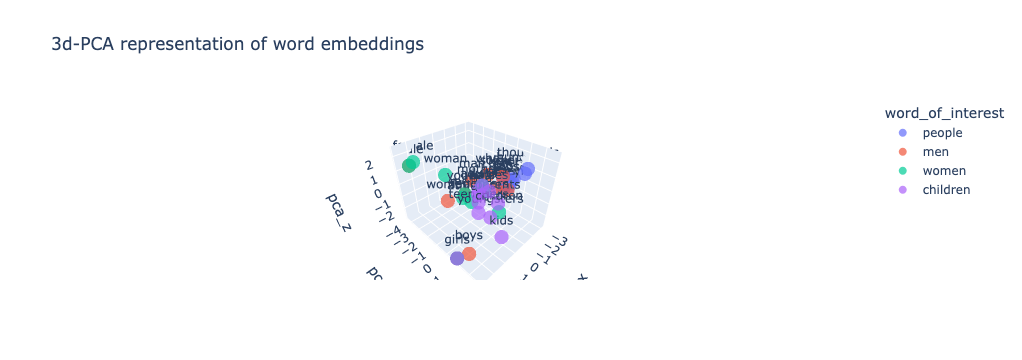

In [24]:
from sklearn.decomposition import PCA
#pandas is a library for data analysis and manipulation, use particularly for tabular data (like in an excel)
import pandas as pd
import numpy as np
import plotly.express as px

words_of_interest = ["people", "men", "women", "children"]
#we make a single array with the top10 most similar words to those in words_of_interest
clusters=[]
for word in words_of_interest:
  clusters.extend([k for k,v in embeddings.most_similar(word)])

#we perform PCA on the list of top10 words
pca = PCA(n_components=3) #Perform 3d-PCA
embeddings_pca = pca.fit_transform(embeddings[clusters])

#we save the results of PCA in a dataframe (tabular format)
pca_df = pd.DataFrame(embeddings_pca, columns=["pca_x", "pca_y", "pca_z"])
#we add a column 'word' with the corresponding top10 words for each coordinates
pca_df["word"] = clusters
#we add a column 'word_of_interest' with the most similar word in words_of_interest
labels = np.array(words_of_interest).repeat(10)
pca_df["word_of_interest"] = labels

#we visualize the first 10 rows of the dataframe
print(pca_df)
#we create a plot
fig = px.scatter_3d(pca_df, x='pca_x', y='pca_y', z='pca_z', color="word_of_interest", text="word", opacity=0.7, title="3d-PCA representation of word embeddings")
fig.show()

## Word embedding evaluation

There are two main types of evaluation for word embeddings:
   
   * **intrisic evaluation**: where we evaluate word embeddings on the embedding space
        * word similarity benchmarks
        * word analogy benchmarks
   * **extrinsic evaluation**: where we evaluate word embeddings on a downstream task, like text classification.


We will see how intrisic evaluation works.

### Word Similarity benchmarks

Word similarity benchmarks, are datasets that contain pairs of words and a similarity score between each given by human heuristic judgments. The higher the correlation between the assigned human similarity score and the actual similarity between the obtained embeddings, the better the embeddings are.


One of these datasets is [MEN](https://staff.fnwi.uva.nl/e.bruni/MEN) that contains a total of 3000 scored pairs.


In [30]:
import pandas as pd
# we read MEN as a dataframe
ws_df = pd.read_csv('./Lab_2_datasets/men.csv', sep=",")
# let's see a portion of the dataset
ws_df.sample(10)

,word1,word2,similarity
2832,museum,swim,6.0
2556,display,pond,10.0
1189,cold,water,30.0
2667,abandon,button,9.0
1418,cottage,sleep,27.0
2259,dead,face,14.0
975,bacon,eat,33.0
2079,happy,toe,16.0
1357,patio,stair,28.0
854,eat,meat,35.0


To evaluate word embeddings on a word similarity benchmark, we need to do these steps:

1. For each pair of words $(w_{i_{1}}, w_{i_{2}})$ in the benchmark, we compute the cosine similarity between its word embeddings $\cos(\mathbf{e}_{w_{i_{1}}}, \mathbf{e}_{w_{i_{2}}})$
2. We compute a correlation score (like [Pearson's $r$](https://en.wikipedia.org/wiki/Pearson_correlation_coefficient) or [Spearman's $\rho$](https://en.wikipedia.org/wiki/Spearman%27s_rank_correlation_coefficient)) between the human given scores and the cosine similarities between the embeddings
    - the higher the score, the better!

Gensim has a function that does all of that: [```evaluate_word_pairs```](https://radimrehurek.com/gensim/models/keyedvectors.html#gensim.models.keyedvectors.KeyedVectors.evaluate_word_pairs), it computes the correlation between the model with human similarity judgments in a dataset.

In [31]:
embeddings.evaluate_word_pairs('./Lab_2_datasets/men.csv', delimiter=',')

(PearsonRResult(statistic=np.float64(0.7297760672040572), pvalue=np.float64(0.0)),
 SignificanceResult(statistic=np.float64(0.7374646969805516), pvalue=np.float64(0.0)),
 0.0)

### Word Analogy benchmarks

Word analogy benchmarks are datasets that contain groups of four words that are related in some way.  The evaluation of the embeddings is based on the idea that this relations can be predicted by arithmetic operations in the vectorial space.

Given $\mathbf{e}_x$ to be the embedding of word $x$, examples of the relations that can be found in these datasets and how they are verified are:

*    man : king = woman : queen -> $\mathbf{e}_{king} - \mathbf{e}_{man} + \mathbf{e}_{woman} = \mathbf{e}_x$ where $x$ is checked to be $queen$.
*    miss : woman = mr : man -> $\mathbf{e}_{woman} - \mathbf{e}_{miss} + \mathbf{e}_{mr} = \mathbf{e}_x$ where $x=man$
*    athens : greece = madrid : spain -> $\mathbf{e}_{greece} - \mathbf{e}_{athens} + \mathbf{e}_{madrid} = \mathbf{e}_x$ where $x=spain$


To verify these relations we can use Gensim `most_similar` function, that we already saw. Word embedding that we would sum together are those that **contribute positively**, the one that we subtract have a **negative contribution**.

In [32]:
print(embeddings.most_similar(positive=["king", "woman"], negative=["man"]))
print(embeddings.most_similar(positive=["woman", "mr"], negative=["miss"]))
print(embeddings.most_similar(positive=["greece", "madrid"], negative=["athens"]))

[('queen', 0.6713277101516724), ('princess', 0.5432624816894531), ('throne', 0.5386104583740234), ('monarch', 0.5347574949264526), ('daughter', 0.4980250597000122), ('mother', 0.49564430117607117), ('elizabeth', 0.483265221118927), ('kingdom', 0.47747087478637695), ('prince', 0.4668239951133728), ('wife', 0.46473270654678345)]
[('man', 0.5249294638633728), ('mr.', 0.4656229615211487), ('husband', 0.41522544622421265), ('person', 0.4119867980480194), ('surnamed', 0.40376853942871094), ('businessman', 0.38730764389038086), ('father', 0.385066956281662), ('himself', 0.3838663697242737), ('mrs', 0.3825554847717285), ('servant', 0.38167592883110046)]
[('spain', 0.7184895277023315), ('portugal', 0.5856314897537231), ('valencia', 0.5343517661094666), ('atletico', 0.5164921283721924), ('argentina', 0.5135518312454224), ('spanish', 0.5101865530014038), ('barcelona', 0.509389340877533), ('italy', 0.5003106594085693), ('morocco', 0.47494179010391235), ('sevilla', 0.46224892139434814)]


We will use a subset of the [SemEval 2017](https://alt.qcri.org/semeval2017/task2/) benchmark that contains 4998 relations. The original dataset contains 10014 entries for the English language.

In [33]:
#we open and visualize a portion of the dataset
f = open('./Lab_2_datasets/semeval.txt')
print("".join(f.readlines()[:10]))
f.close()

: semeval-analogies
water drop hour seconds
mile yard hour seconds
time moment hour seconds
water drop feet inches
mile yard feet inches
time moment feet inches
water drop foot inch
mile yard foot inch
time moment foot inch



Instead of running `most_similar` on each entry, we can use the built-in function [`evaluate_word_analogies`](https://radimrehurek.com/gensim/models/keyedvectors.html#gensim.models.keyedvectors.KeyedVectors.evaluate_word_analogies) which computes the performance of the model over an analogy test set.

In [34]:
accuracy, results = embeddings.evaluate_word_analogies('./Lab_2_datasets/semeval.txt')
print("Accuracy ", accuracy)
print(results[0].keys())
print("Correct ", len(results[0]['correct']) ,results[0]['correct'][:5])
print("Incorrect" , len(results[0]['incorrect']) , results[0]['incorrect'][:5])

Accuracy  0.017575757575757574
dict_keys(['section', 'correct', 'incorrect'])
Correct  87 [('WATER', 'DROP', 'DAY', 'WEEK'), ('MILE', 'YARD', 'DAY', 'WEEK'), ('BRIGHTEN', 'COLOR', 'ACCELERATION', 'SPEED'), ('CRESCENDO', 'SOUND', 'DARKEN', 'COLOR'), ('CRESCENDO', 'SOUND', 'FLOOD', 'WATER')]
Incorrect 4863 [('WATER', 'DROP', 'HOUR', 'SECONDS'), ('MILE', 'YARD', 'HOUR', 'SECONDS'), ('TIME', 'MOMENT', 'HOUR', 'SECONDS'), ('WATER', 'DROP', 'FEET', 'INCHES'), ('MILE', 'YARD', 'FEET', 'INCHES')]


## Semantic Lexicons

A semantic lexicon is a database mapping words to semantic classes or relationships, explicitly represent *word senses* (the different meanings a word can have).



The most widely used collection is [**WordNet**](https://wordnet.princeton.edu/), which organizes word senses into
*synsets* (synonym sets), each representing a distinct concept. For example, the word *bank* has at least two distinct senses: a financial institution and the edge of a river. Each sense is treated as a separate entity, with its own definition, examples and relations (synonymy, hypernymy, hyponymy, antonymy, etc).

 Other useful resources are:
- **PPDB** (Paraphrase Database), containing
  millions of paraphrase pairs extracted from bilingual parallel corpora. The intuition is that if two words in one language translate to the same word in another language, they are likely paraphrases.

- [**FrameNet**](https://framenet.icsi.berkeley.edu/), a linguistic database that groups words by the conceptual *frames*
  they evoke. A frame is an abstract situation or event, and all words that can
  describe it are connected. For example, the frame *motion* groups *direction*, *distance*, *goal*, *path*.

In [36]:
import nltk
from nltk.corpus import wordnet as wn
nltk.download('wordnet')

synsets = wn.synsets("plant") # returns a list of all synsets
print("Number of synsets:", len(synsets))
print(synsets)

# 'plant': lemma, 'n': noun (part of speech),
# '01': sense number (disambiguates between multiple synsets)

# e.g. synset('plant.n.01'): buildings for carrying on industrial labor
# synset('plant.n.09'): (botany) a living organism lacking the power of locomotion

[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/lucapiai/nltk_data...


Number of synsets: 10
[Synset('plant.n.01'), Synset('plant.n.02'), Synset('plant.n.03'), Synset('plant.n.04'), Synset('plant.v.01'), Synset('implant.v.01'), Synset('establish.v.02'), Synset('plant.v.04'), Synset('plant.v.05'), Synset('plant.v.06')]


We can see some relations relative to the specific synsets of interest, such as *"plant.n.01"* and *"plant.n.02"*.

In [37]:
# two different senses of the word "plant"
print("Definition 1:", wn.synset("plant.n.01").definition())
print("Definition 2:", wn.synset("plant.n.02").definition())

# synonyms for each sense
print("\nSynonyms 1:", wn.synset("plant.n.01").lemma_names())
print("Synonyms 2:", wn.synset("plant.n.02").lemma_names())

# hypernyms for each sense (it returns synsets, not strings!!)
print("\nHypernyms 1:", wn.synset("plant.n.01").hypernyms())
print("Hypernyms 2:", wn.synset("plant.n.02").hypernyms())

# hyponyms for each sense (it returns synsets, not strings!!)
print("\nHyponyms 1:", wn.synset("plant.n.01").hyponyms())
print("Hyponyms 2:", wn.synset("plant.n.02").hyponyms())

# we can compute the semantic similarity with 'path_similarity' (1.0 / (shortest path distance + 1))
print(wn.synset("plant.n.01").path_similarity(wn.synset("plant.n.02")))

Definition 1: buildings for carrying on industrial labor
Definition 2: (botany) a living organism lacking the power of locomotion

Synonyms 1: ['plant', 'works', 'industrial_plant']
Synonyms 2: ['plant', 'flora', 'plant_life']

Hypernyms 1: [Synset('building_complex.n.01')]
Hypernyms 2: [Synset('organism.n.01')]

Hyponyms 1: [Synset('saltworks.n.01'), Synset('mint.n.06'), Synset('bottling_plant.n.01'), Synset('factory.n.01'), Synset('distillery.n.01'), Synset('smelter.n.01'), Synset('sewage_disposal_plant.n.01'), Synset('brewery.n.01'), Synset('packinghouse.n.02'), Synset('recycling_plant.n.01'), Synset('refinery.n.01')]
Hyponyms 2: [Synset('neophyte.n.01'), Synset('cryptogam.n.01'), Synset('poisonous_plant.n.01'), Synset('acrogen.n.01'), Synset('microflora.n.01'), Synset('rock_plant.n.01'), Synset('garden_plant.n.01'), Synset('autophyte.n.01'), Synset('perennial.n.01'), Synset('non-flowering_plant.n.01'), Synset('apomict.n.01'), Synset('air_plant.n.01'), Synset('vascular_plant.n.01'),


If we want to access lexical information (hyponyms in this case) for all meanings of a word,
we must iterate over all its synsets!

In [38]:
for hyper in wn.synset("plant.n.01").hyponyms():
  print("-", hyper.name(), ":", hyper.definition())

- saltworks.n.01 : a plant where salt is produced commercially
- mint.n.06 : a plant where money is coined by authority of the government
- bottling_plant.n.01 : a plant where beverages are put into bottles with caps
- factory.n.01 : a plant consisting of one or more buildings with facilities for manufacturing
- distillery.n.01 : a plant and works where alcoholic drinks are made by distillation
- smelter.n.01 : an industrial plant for smelting
- sewage_disposal_plant.n.01 : a plant for disposing of sewage
- brewery.n.01 : a plant where beer is brewed by fermentation
- packinghouse.n.02 : a plant where livestock are slaughtered and processed and packed as meat products
- recycling_plant.n.01 : a plant for reprocessing used or abandoned materials
- refinery.n.01 : an industrial plant for purifying a crude substance


In WordNet, a lemma represents a specific word form within a synset.
Unlike `.lemma_names()`, which returns a list of strings, `.lemmas()` returns Lemma objects that contain additional linguistic information, such as antonyms or frequency.

Since antonyms are defined at the lemma level (not the synset level), they can only be accessed through lemma objects. To access lemma-level attributes, you must first retrieve the lemma objects via `.lemmas()`.

Let's check the antonyms of the synset "*good.a.01*":

In [39]:
# let's check the definition first
print("Definition 1:", wn.synset("good.a.01").definition())

# antonyms are defined at the lemma level, so we must iterate over lemma objects
# of a specific synset (in this case, a specific meaning of "good")
for lemma in wn.synset("good.a.01").lemmas():

    # lemma.antonyms() returns a list of opposite Lemma objects (if any exist)
    if lemma.antonyms():

        # we take the first antonym and print its name (string form)
        print("Antonyms:", lemma.antonyms()[0].name())

Definition 1: having desirable or positive qualities especially those suitable for a thing specified
Antonyms: bad
